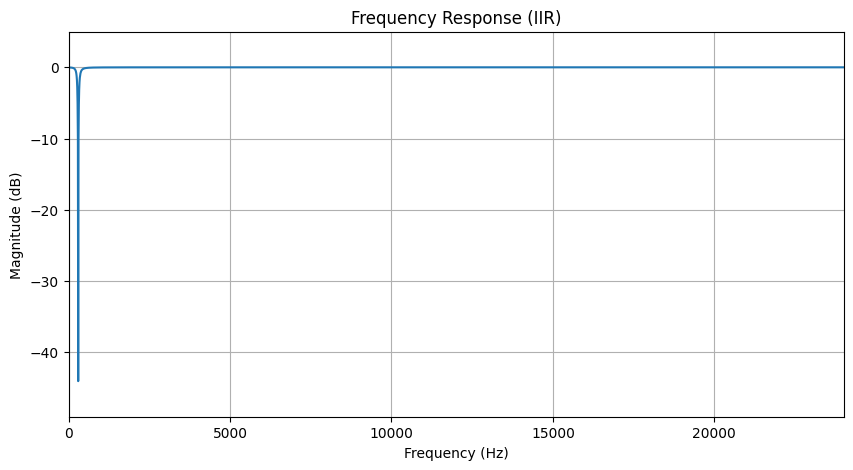

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
fs = 48000
nFreqs = 4800

# Coefficienti del filtro (numeratore e denominatore)
b = np.array([1, -1.99846, 1])
a = np.array([1.00393, -1.99846, 0.996074])

# Frequenze normalizzate in [0, 2π)
omega = 2 * np.pi * np.arange(nFreqs) / nFreqs

# Calcolo H(e^jω)
def freq_response(b, a, omega):
    k_b = np.arange(len(b))
    k_a = np.arange(len(a))
    Hnum = np.array([np.sum(b * np.exp(-1j * w * k_b)) for w in omega])
    Hden = np.array([np.sum(a * np.exp(-1j * w * k_a)) for w in omega])
    return Hnum / Hden

H = freq_response(b, a, omega)

# Conversione frequenze in Hz
freqsHz = omega * fs / (2 * np.pi)

# Magnitudine in dB (+ epsilon per evitare log(0))
magnitude_dB = 20 * np.log10(np.abs(H) + 1e-12)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(freqsHz, magnitude_dB)
plt.title("Frequency Response (IIR)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.xlim(0, fs / 2)
plt.ylim(np.min(magnitude_dB) - 5, np.max(magnitude_dB) + 5)
plt.show()


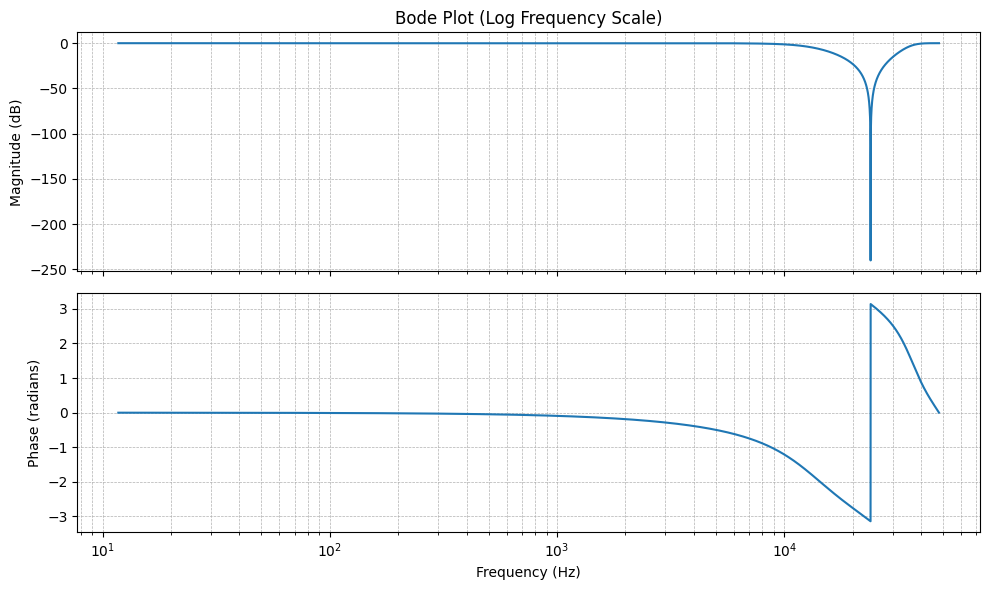

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
fs = 48000
nFreqs = 4096

# Coefficienti filtro
b = np.array([0.2929, 0.5858, 0.2929])
a = np.array([1.0, 0.0, 0.1716])

# Frequenze normalizzate
omega = 2 * np.pi * np.arange(1, nFreqs) / nFreqs  # salta ω=0 per log scale

# Funzione di trasferimento H(e^jω)
def freq_response(b, a, omega):
    k_b = np.arange(len(b))
    k_a = np.arange(len(a))
    Hnum = np.array([np.sum(b * np.exp(-1j * w * k_b)) for w in omega])
    Hden = np.array([np.sum(a * np.exp(-1j * w * k_a)) for w in omega])
    return Hnum / Hden

H = freq_response(b, a, omega)

# Conversione frequenze in Hz
freqsHz = omega * fs / (2 * np.pi)

# Magnitudine in dB
magnitude_dB = 20 * np.log10(np.abs(H) + 1e-12)

# Fase in radianti (unwrap per continuità)
phase_rad = np.unwrap(np.angle(H))

# --- Bode Plot con assi logaritmici ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Magnitudine
ax1.plot(freqsHz, magnitude_dB)
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("Bode Plot (Log Frequency Scale)")
ax1.set_xscale('log')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Fase
ax2.plot(freqsHz, phase_rad)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Phase (radians)")
ax2.set_xscale('log')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()
